<a href="https://colab.research.google.com/github/nobg0321/ABCD-A/blob/20250515_middletest/v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎉 'cat_photo.jpg' 파일이 확인되었어요. 분석을 시작합니다!
📦 YOLOv8 모델 로딩 중 (yolov8n)

image 1/1 /content/cat_photo.jpg: 640x640 3 cats, 4 dogs, 9.3ms
Speed: 3.9ms preprocess, 9.3ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

🐱 고양이 탐지 결과: 3마리 찾았어요!


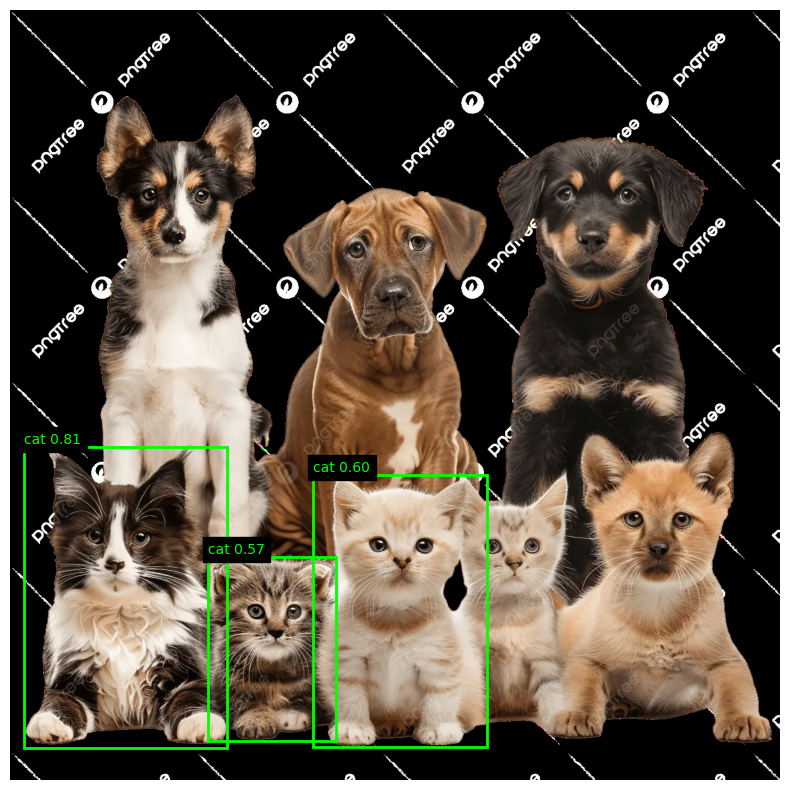

💾 결과 이미지가 저장되었습니다: /content/cat_detected.jpg


In [ ]:
# YOLOv8 설치 (코랩에서 최초 1회만 실행)
!pip install -U ultralytics

# 코드 실행
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from ultralytics import YOLO

# 설정
image_filename = 'cat_photo.jpg'  # 코랩에 업로드한 고양이 이미지 이름
image_path = f'/content/{image_filename}'
output_path = '/content/cat_detected.jpg'
confidence_threshold = 0.5  # 신뢰도 임계값

def load_model():
    print("📦 YOLOv8 모델 로딩 중 (yolov8n)")
    return YOLO('yolov8n.pt')  # 다른 모델: yolov8s.pt, yolov8m.pt 등

def detect_objects(model, img_path):
    results = model(img_path)[0]
    return Image.open(img_path).convert("RGB"), results

def filter_detections(results, class_name='cat', threshold=0.5):
    detections = []
    for box in results.boxes:
        cls_id = int(box.cls.item())
        conf = box.conf.item()
        if conf > threshold and results.names[cls_id] == class_name:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            detections.append((x1, y1, x2, y2, conf))
    return detections

def draw_boxes_and_save(img, detections, output_path, box_color='lime', label='cat'):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)

    for x1, y1, x2, y2, score in detections:
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor=box_color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{label} {score:.2f}",
                color=box_color, fontsize=10, backgroundcolor='black')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

# 실행
if not os.path.exists(image_path):
    print(f"🚨 에러: '{image_filename}' 파일이 존재하지 않아요. /content/ 경로에 업로드되었는지 확인해주세요.")
else:
    print(f"🎉 '{image_filename}' 파일이 확인되었어요. 분석을 시작합니다!")

    model = load_model()
    img, results = detect_objects(model, image_path)
    cat_detections = filter_detections(results, class_name='cat', threshold=confidence_threshold)

    print(f"\n🐱 고양이 탐지 결과: {len(cat_detections)}마리 찾았어요!")
    draw_boxes_and_save(img, cat_detections, output_path)

    print(f"💾 결과 이미지가 저장되었습니다: {output_path}")
